# Post Hoc Power Analysis

## Setup

In [ ]:

library(here)


here() starts at C:/Users/pablo/OneDrive/Github/cfa-power

This is lavaan 0.6-21
lavaan is FREE software! Please report any bugs.

###############################################################################

This is semTools 0.5-8

All users of R (or SEM) are invited to submit functions or ideas for functions.

...


Attaching package: 'dplyr'

The following object is masked from 'package:MASS':

    select

The following objects are masked from 'package:stats':

    filter, lag

The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union

Loading required package: SparseM

In [ ]:

url_data <- "https://data.mendeley.com/datasets/rdky78bk8r/2/files/b58a7054-4978-4239-81db-00f9efd86e44/WHOQOL_Data.dat"
realdata <- read.table(url_data)

url_labels <- "https://data.mendeley.com/datasets/rdky78bk8r/2/files/ae2a5c01-2fc2-43e5-b31c-8db8cc5bff8a/WHOQOL_Labels.txt"
column_labels <- read.table(url_labels)
column_labels <- column_labels$V1
names(realdata) <- gsub("_[FPSA]$", "", column_labels)

n_real <- nrow(realdata) # Sample size of the real data

df_model <- semPower::semPower.getDf(analyzemodel) # Degrees of freedom for the model, needed for semPower post hoc


## Post hoc power analysis

### With simulation

- Passo 1: Ajustar o modelo aos dados reais

In [ ]:

fit_real <- cfa(
  analyzemodel,
  data = realdata,
  estimator = "mlr"
)


- Passo 2: Simular modelo nulo com N real

In [ ]:

realmodel_null <- cache_or_run("realmodel_null", {
  sim(
      nRep      = REP,        # See the `REP` object defined in helpers.R for the number of replications used in this scenario.
      n         = n_real,
      analyzemodel,
      generate  = fit_real,
      std.lv    = TRUE,
      lavaanfun = "cfa",
      estimator = "mlr",
      seed      = SEED,
      multicore = TRUE
  )
})


- Passo 3: Simular modelo alternativo com N real

In [ ]:

h1model_alt <- cache_or_run("h1model_alt", {
  sim(
      nRep      = REP,        # See the `REP` object defined in helpers.R for the number of replications used in this scenario.
      n         = n_real,
      analyzemodel,
      generate  = h1model,
      std.lv    = TRUE,
      lavaanfun = "cfa",
      estimator = "mlr",
      seed      = SEED,
      multicore = TRUE
  )
})


- Passo 4: Poder no N coletado

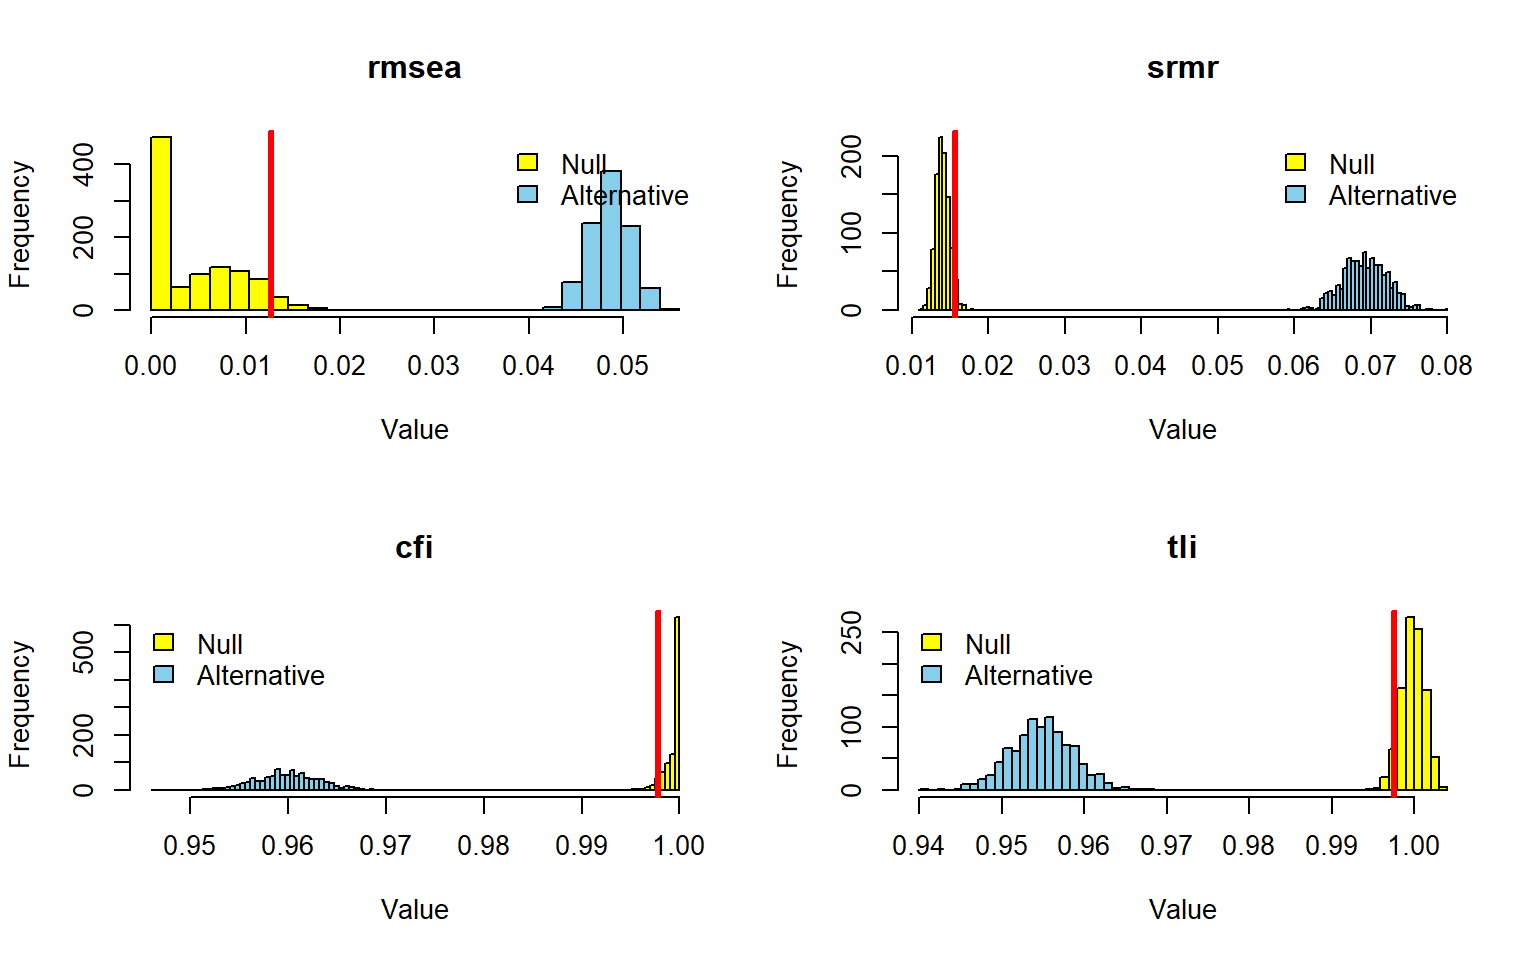

In [ ]:

plotPowerFit(
    h1model_alt,
    nullObject = realmodel_null,
    alpha      = ALPHA,
    usedFit    = FITS
)


``` r

getPowerFit(
    h1model_alt,
    nullObject = realmodel_null,
    alpha      = ALPHA,
    usedFit    = FITS
)
```

    TraditionalChi          rmsea           srmr            cfi            tli 
                 1              1              1              1              1 

### With semPower


 semPower: Post hoc power analysis
                                      
 F0                       0.622500    
 RMSEA                    0.050000    
 Mc                       0.732531    
 GFI                      0.950683    
 AGFI                     0.940582    
                                      
 df                       249         
 Num Observations         1047        
 NCP                      651.1350    
                                      
 Critical Chi-Square      286.8077    
 Alpha                    0.050000    
 Beta                     4.771426e-48
 Power (1 - Beta)         > 0.9999    
 Implied Alpha/Beta Ratio 1.047905e+46

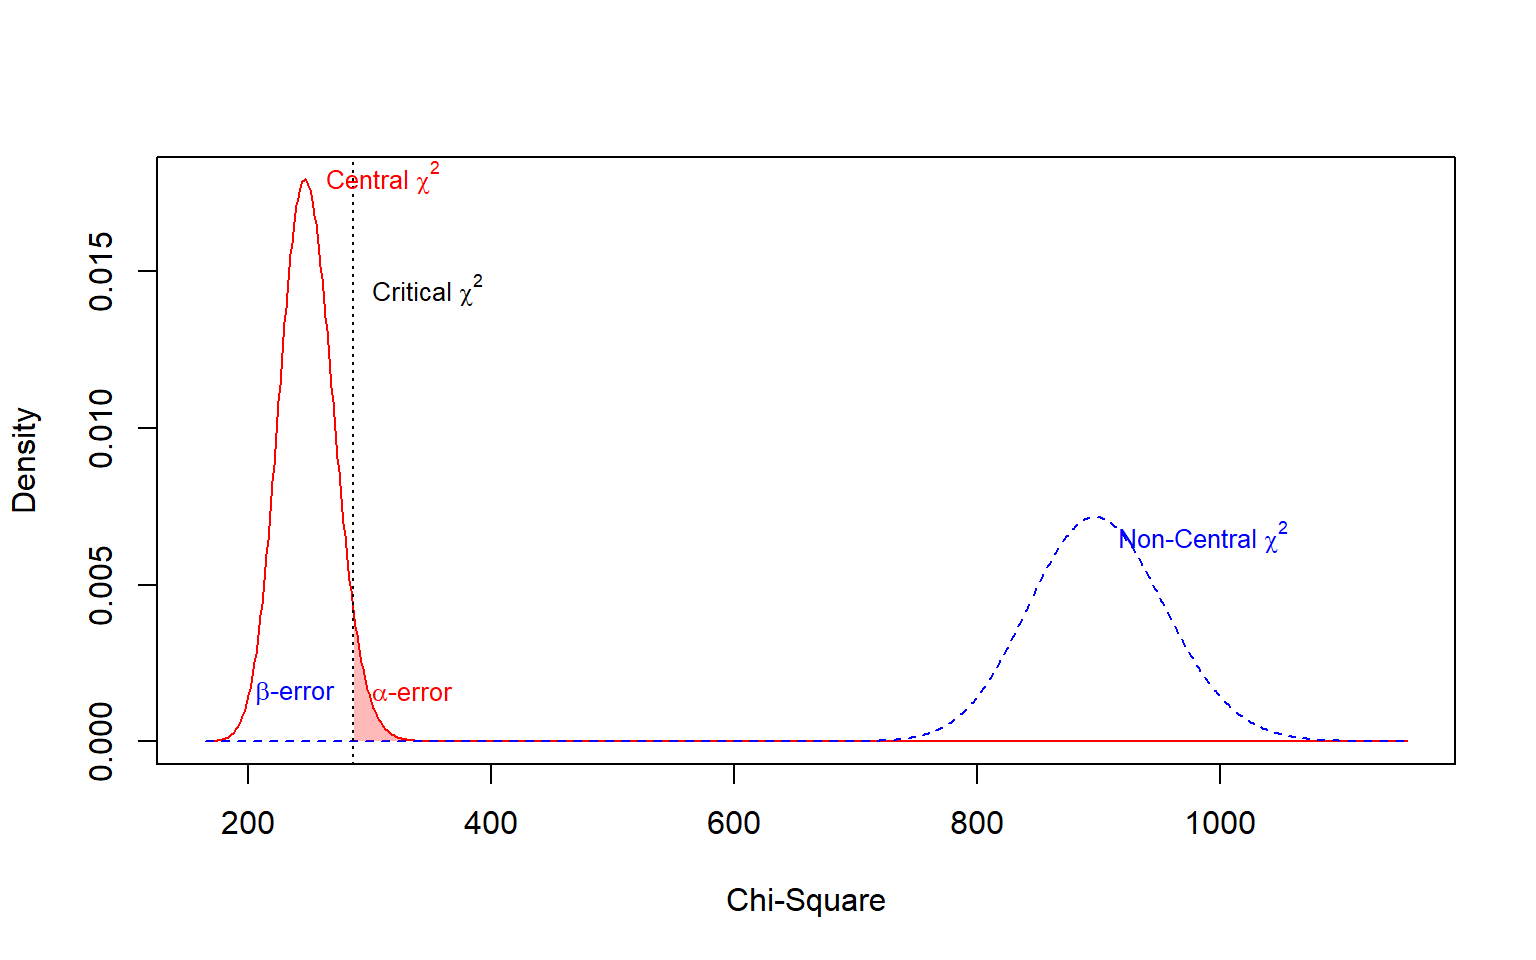

In [ ]:

ph_rsmea <- semPower::semPower.postHoc(
    effect         = 0.05,
    effect.measure = "RMSEA",  # RMSEA under H1 (exact-fit model: H0: RMSEA = 0)
    alpha          = ALPHA,
    N              = n_real,
    df             = df_model,
    p              = P         # Just for GFI and AGFI
)

summary(ph_rsmea)



 semPower: Post hoc power analysis
                                      
 F0                       0.303870    
 RMSEA                    0.034934    
 SRMR                     0.175600    
 Mc                       0.859044    
 GFI                      0.975303    
 AGFI                     0.970244    
 CFI                      0.977582    
                                      
 df                       249         
 Num Observations         1047        
 NCP                      317.8482    
                                      
 Critical Chi-Square      286.8077    
 Alpha                    0.050000    
 Beta                     6.740368e-16
 Power (1 - Beta)         > 0.9999    
 Implied Alpha/Beta Ratio 7.417993e+13

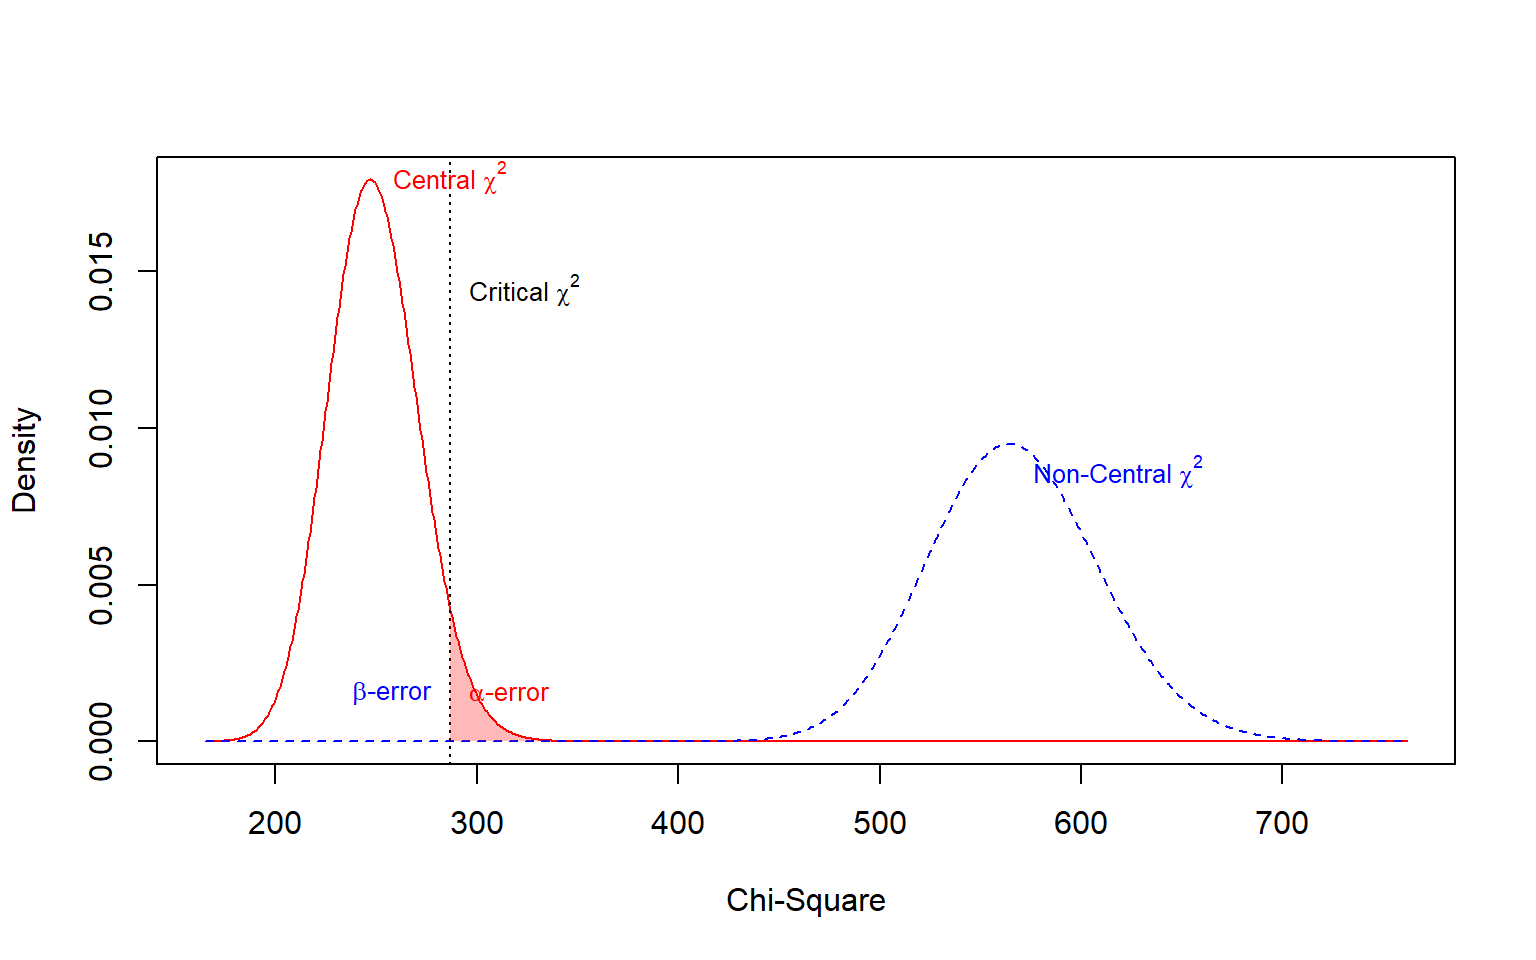

In [ ]:

ph_realmodel <- semPower.powerLav(
  type = 'post-hoc',
  alpha = ALPHA,
  N = n_real,
  modelPop = popmodel,
  modelH0 = fit_real,
)

summary(ph_realmodel)


Warning in semPower.powerLav(type = "post-hoc", alpha = ALPHA, N = n_real, : H1
model yields imperfect fit (F0 = 0.294788). This may happen if the H1 model
contains restrictions on parameters (such as invariance constraints) that
actually differ in the population. Verify that this is intended.


 semPower: Post hoc power analysis
                                  
 F0                       0.009082
 RMSEA                    0.055021
 Mc                       0.995469
                                  
 df                       3       
 Num Observations         1047    
 NCP                      9.499715
                                  
 Critical Chi-Square      7.814728
 Alpha                    0.050000
 Beta                     0.262955
 Power (1 - Beta)         0.737045
 Implied Alpha/Beta Ratio 0.190147

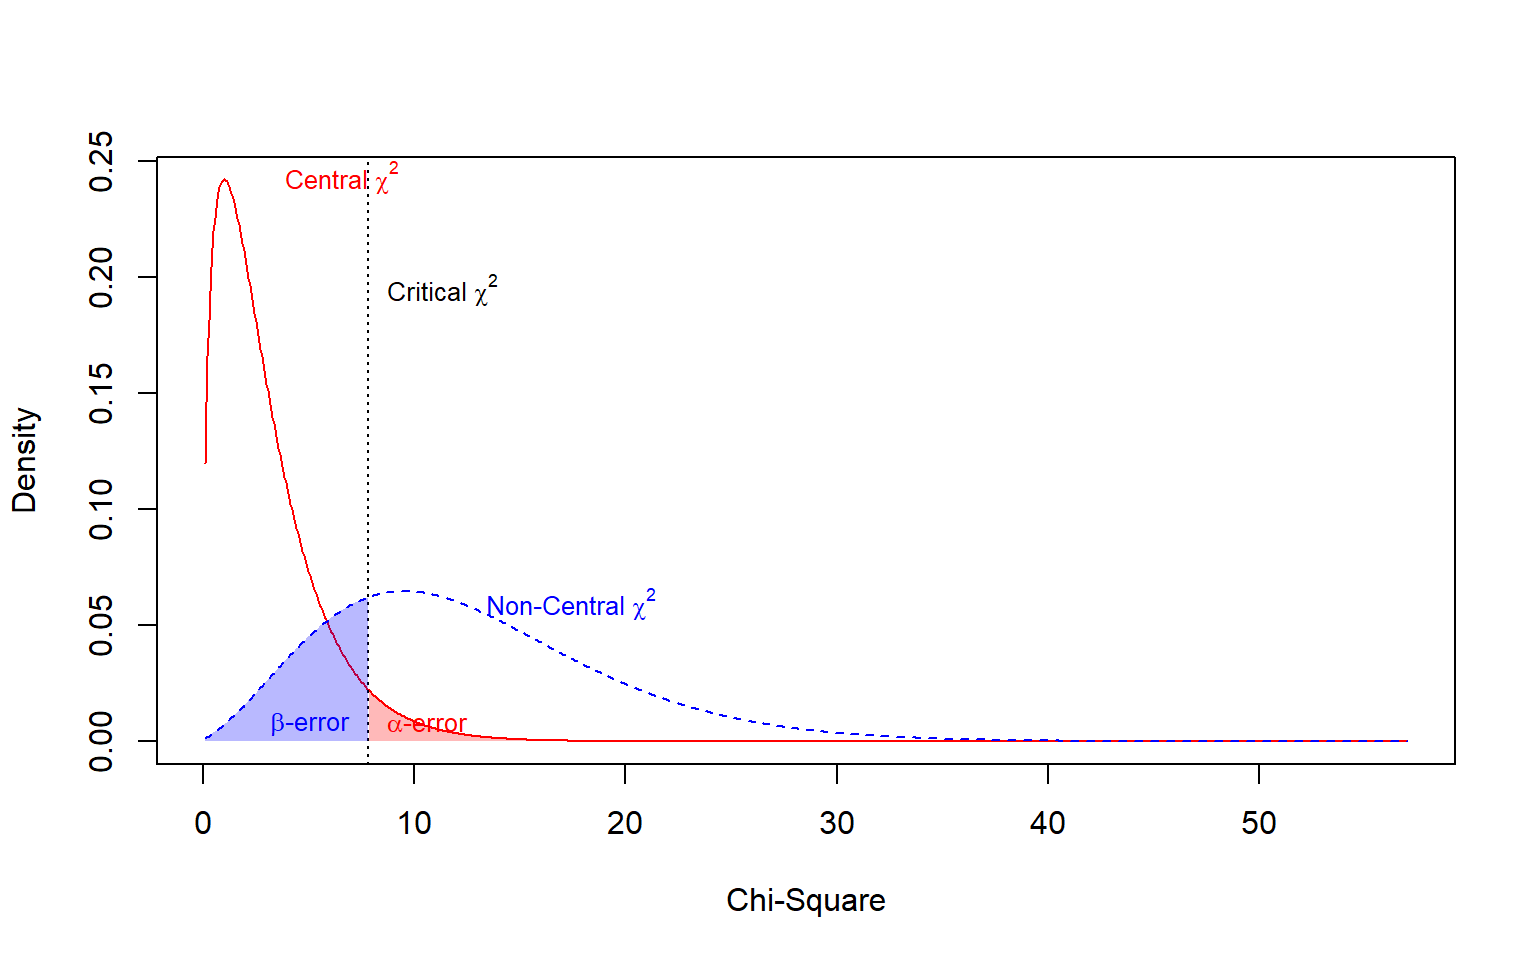

In [ ]:

ph_posthoc_miss <- semPower.powerLav(
  type = 'post-hoc',
  alpha = ALPHA,
  N = n_real,
  modelPop = popmodel,
  modelH0 = fit_real,
  modelH1 = h1modelfree
)
